In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# USER SETTINGS
# ============================================================
input_nc = Path("../data/GPGP_aug2020_3D_22.05-23.95N_141.05-139.05W-3.nc")
out_dir = Path("../data")
out_stem = "MITgcm_interp_aug2020"

# MITgcm target grid arrays (cell centers)
Lx = 384 * 500.0
Ly = 384 * 500.0

x_mit = np.arange(-Lx/2, Lx/2, 500.0, dtype=float)
y_mit = np.arange(-Ly/2, Ly/2, 500.0, dtype=float)

delR = np.array([
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0,
    2.2, 2.4, 2.6, 2.9, 3.1,
    3.4, 3.7, 4.0, 4.4, 4.8,
    5.2, 5.7, 6.2, 6.8, 7.4,
    8.1, 8.8, 9.6, 10.5, 11.4,
    12.5, 13.6, 14.8, 16.2, 17.6,
    19.2, 21.0, 22.9, 24.9, 27.2,
    29.7, 32.4, 35.4, 38.6, 42.1,
    45.9, 50.0, 54.5, 59.4, 64.8,
    70.6, 77.0, 84.0, 91.5, 99.7,
    108.7, 118.5, 129.1, 140.8, 153.5,
    167.3, 182.4, 198.8, 216.7, 236.2,
    257.5, 280.7, 306.1, 328.5
], dtype=float)

z_mit = np.cumsum(delR) - 0.5 * delR

method_main = "linear"
method_fallback = "nearest"

# ------------------------------------------------------------
# FIGURE OUTPUT SETTINGS
# ------------------------------------------------------------
figures_dir = Path('../figures')
save_format = 'png'

# ============================================================
# HELPERS
# ============================================================

def _sanitize_filename(name):
    name = str(name)
    safe = ''.join(c if c.isalnum() or c in '._-' else '_' for c in name.strip())
    return safe.strip('._-') or 'figure'

def figure_output_path(name, fmt=save_format):
    if out_stem is None:
        raise ValueError('out_stem must be set to save figures')
    out_dir_fig = figures_dir / out_stem
    out_dir_fig.mkdir(parents=True, exist_ok=True)
    return out_dir_fig / f"{_sanitize_filename(name)}.{fmt}"

def find_first_present(ds, names):
    for n in names:
        if n in ds.variables or n in ds.coords:
            return n
    return None

def centers_to_faces_1d(xc):
    xc = np.asarray(xc, dtype=float)
    xf = np.empty(len(xc) + 1, dtype=float)
    xf[1:-1] = 0.5 * (xc[:-1] + xc[1:])
    xf[0] = xc[0] - 0.5 * (xc[1] - xc[0])
    xf[-1] = xc[-1] + 0.5 * (xc[-1] - xc[-2])
    return xf

def xy_to_lonlat(x, y, lon0, lat0):
    Re = 6371000.0
    lat = lat0 + (y / Re) * 180.0 / np.pi
    lon = lon0 + (x / (Re * np.cos(np.deg2rad(lat0)))) * 180.0 / np.pi
    return lon, lat

def fill_nan_vertical(arr, zsrc):
    out = arr.copy()
    nz, ny, nx = out.shape
    for j in range(ny):
        for i in range(nx):
            col = out[:, j, i]
            good = np.isfinite(col)
            if good.any():
                if good.sum() == 1:
                    col[:] = col[good][0]
                else:
                    col[~good] = np.interp(
                        zsrc[~good], zsrc[good], col[good],
                        left=col[good][0], right=col[good][-1]
                    )
            else:
                col[:] = 0.0
            out[:, j, i] = col
    return out

# ============================================================
# OPEN DATA
# ============================================================
ds = xr.open_dataset(input_nc)

u_name = find_first_present(ds, ["uo", "UO", "u", "U"])
v_name = find_first_present(ds, ["vo", "VO", "v", "V"])
theta_name = find_first_present(ds, ["thetao", "THETAO", "theta", "THETA", "temperature", "temp", "TEMP"])
salt_name = find_first_present(ds, ["so", "SO", "salt", "SALT", "salinity", "vosaline"])
lon_name = find_first_present(ds, ["longitude", "lon", "nav_lon"])
lat_name = find_first_present(ds, ["latitude", "lat", "nav_lat"])
z_name = find_first_present(ds, ["depth", "lev", "z"])
time_name = find_first_present(ds, ["time", "TIME"])

if None in [u_name, v_name, theta_name, salt_name, lon_name, lat_name, z_name]:
    raise ValueError("Could not automatically identify u, v, theta, salt, lon, lat, or depth variables.")

u_da = ds[u_name].isel({time_name: 0}) if time_name and time_name in ds[u_name].dims else ds[u_name]
v_da = ds[v_name].isel({time_name: 0}) if time_name and time_name in ds[v_name].dims else ds[v_name]
theta_da = ds[theta_name].isel({time_name: 0}) if time_name and time_name in ds[theta_name].dims else ds[theta_name]
salt_da = ds[salt_name].isel({time_name: 0}) if time_name and time_name in ds[salt_name].dims else ds[salt_name]

lon_src = np.asarray(ds[lon_name].values, dtype=float)
lat_src = np.asarray(ds[lat_name].values, dtype=float)
z_src = np.asarray(ds[z_name].values, dtype=float)

# sort longitude
lon_sort_idx = np.argsort(lon_src)
lon_src = lon_src[lon_sort_idx]

# sort latitude too if needed
if np.any(np.diff(lat_src) < 0):
    lat_sort_idx = np.argsort(lat_src)
    lat_src = lat_src[lat_sort_idx]
    lat_sorted = True
else:
    lat_sort_idx = None
    lat_sorted = False

u_src = np.asarray(u_da.values, dtype=np.float32)
v_src = np.asarray(v_da.values, dtype=np.float32)
theta_src = np.asarray(theta_da.values, dtype=np.float32)
salt_src = np.asarray(salt_da.values, dtype=np.float32)

# expected after time selection: (z, y, x)
u_src = u_src[:, :, lon_sort_idx]
v_src = v_src[:, :, lon_sort_idx]
theta_src = theta_src[:, :, lon_sort_idx]
salt_src = salt_src[:, :, lon_sort_idx]

if lat_sorted:
    u_src = u_src[:, lat_sort_idx, :]
    v_src = v_src[:, lat_sort_idx, :]
    theta_src = theta_src[:, lat_sort_idx, :]
    salt_src = salt_src[:, lat_sort_idx, :]

# keep only needed depth range
iz = z_src <= z_mit.max()
z_src = z_src[iz]
u_src = u_src[iz, :, :]
v_src = v_src[iz, :, :]
theta_src = theta_src[iz, :, :]
salt_src = salt_src[iz, :, :]

# fill NaNs vertically
u_src = fill_nan_vertical(u_src, z_src).astype(np.float32)
v_src = fill_nan_vertical(v_src, z_src).astype(np.float32)
theta_src = fill_nan_vertical(theta_src, z_src).astype(np.float32)
salt_src = fill_nan_vertical(salt_src, z_src).astype(np.float32)

# ============================================================
# BUILD MITgcm U/V/T GRIDS FROM FILE EXTENT
# ============================================================
lon_w = float(np.nanmin(ds[lon_name].values))
lon_e = float(np.nanmax(ds[lon_name].values))
lat_s = float(np.nanmin(ds[lat_name].values))
lat_n = float(np.nanmax(ds[lat_name].values))

lon0 = 0.5 * (lon_w + lon_e)
lat0 = 0.5 * (lat_s + lat_n)

# staggered U grid
x_u = centers_to_faces_1d(x_mit)
y_u = y_mit

# staggered V grid
x_v = x_mit
y_v = centers_to_faces_1d(y_mit)

# tracer grid
x_t = x_mit
y_t = y_mit

X_u, Y_u = np.meshgrid(x_u, y_u)
X_v, Y_v = np.meshgrid(x_v, y_v)
X_t, Y_t = np.meshgrid(x_t, y_t)

Lon_u, Lat_u = xy_to_lonlat(X_u, Y_u, lon0, lat0)
Lon_v, Lat_v = xy_to_lonlat(X_v, Y_v, lon0, lat0)
Lon_t, Lat_t = xy_to_lonlat(X_t, Y_t, lon0, lat0)

# match longitude convention
if lon_src.max() > 180.0:
    Lon_u = np.mod(Lon_u, 360.0)
    Lon_v = np.mod(Lon_v, 360.0)
    Lon_t = np.mod(Lon_t, 360.0)
else:
    Lon_u = ((Lon_u + 180.0) % 360.0) - 180.0
    Lon_v = ((Lon_v + 180.0) % 360.0) - 180.0
    Lon_t = ((Lon_t + 180.0) % 360.0) - 180.0

# ============================================================
# COVERAGE CHECK
# ============================================================
print("GLORYS source ranges:")
print("  lon:", lon_src.min(), lon_src.max())
print("  lat:", lat_src.min(), lat_src.max())
print("  z  :", z_src.min(), z_src.max())

print("\nMapped MITgcm ranges:")
print("  U lon:", np.nanmin(Lon_u), np.nanmax(Lon_u))
print("  U lat:", np.nanmin(Lat_u), np.nanmax(Lat_u))
print("  V lon:", np.nanmin(Lon_v), np.nanmax(Lon_v))
print("  V lat:", np.nanmin(Lat_v), np.nanmax(Lat_v))
print("  T lon:", np.nanmin(Lon_t), np.nanmax(Lon_t))
print("  T lat:", np.nanmin(Lat_t), np.nanmax(Lat_t))
print("  z    :", z_mit.min(), z_mit.max())

u_outside = (
    (Lon_u < lon_src.min()) | (Lon_u > lon_src.max()) |
    (Lat_u < lat_src.min()) | (Lat_u > lat_src.max())
)
v_outside = (
    (Lon_v < lon_src.min()) | (Lon_v > lon_src.max()) |
    (Lat_v < lat_src.min()) | (Lat_v > lat_src.max())
)
t_outside = (
    (Lon_t < lon_src.min()) | (Lon_t > lon_src.max()) |
    (Lat_t < lat_src.min()) | (Lat_t > lat_src.max())
)

print("\nOutside horizontal GLORYS support:")
print(f"  U points: {u_outside.sum()} / {u_outside.size}")
print(f"  V points: {v_outside.sum()} / {v_outside.size}")
print(f"  T/S points: {t_outside.sum()} / {t_outside.size}")

# ============================================================
# INTERPOLATORS
# ============================================================
Fu = RegularGridInterpolator(
    (z_src, lat_src, lon_src),
    u_src,
    method=method_main,
    bounds_error=False,
    fill_value=np.nan
)
Fv = RegularGridInterpolator(
    (z_src, lat_src, lon_src),
    v_src,
    method=method_main,
    bounds_error=False,
    fill_value=np.nan
)
Ftheta = RegularGridInterpolator(
    (z_src, lat_src, lon_src),
    theta_src,
    method=method_main,
    bounds_error=False,
    fill_value=np.nan
)
Fsalt = RegularGridInterpolator(
    (z_src, lat_src, lon_src),
    salt_src,
    method=method_main,
    bounds_error=False,
    fill_value=np.nan
)

Fu_nn = RegularGridInterpolator(
    (z_src, lat_src, lon_src),
    u_src,
    method=method_fallback,
    bounds_error=False,
    fill_value=0.0
)
Fv_nn = RegularGridInterpolator(
    (z_src, lat_src, lon_src),
    v_src,
    method=method_fallback,
    bounds_error=False,
    fill_value=0.0
)
Ftheta_nn = RegularGridInterpolator(
    (z_src, lat_src, lon_src),
    theta_src,
    method=method_fallback,
    bounds_error=False,
    fill_value=0.0
)
Fsalt_nn = RegularGridInterpolator(
    (z_src, lat_src, lon_src),
    salt_src,
    method=method_fallback,
    bounds_error=False,
    fill_value=0.0
)

# ============================================================
# INTERPOLATE U TO U-POINTS, LEVEL BY LEVEL
# ============================================================
Nr = len(z_mit)
Ny_u, Nx_u = Lon_u.shape
u_mit = np.empty((Nr, Ny_u, Nx_u), dtype=np.float32)

for k, zk in enumerate(z_mit):
    print(f"Interpolating U level {k+1}/{Nr} at z = {zk:.2f} m")

    pts_u = np.column_stack([
        np.full(Lon_u.size, zk, dtype=float),
        Lat_u.ravel(),
        Lon_u.ravel()
    ])

    uk = Fu(pts_u).reshape(Ny_u, Nx_u)
    mask = ~np.isfinite(uk)
    if mask.any():
        uk[mask] = Fu_nn(pts_u).reshape(Ny_u, Nx_u)[mask]

    u_mit[k, :, :] = uk.astype(np.float32)

# ============================================================
# INTERPOLATE V TO V-POINTS, LEVEL BY LEVEL
# ============================================================
Ny_v, Nx_v = Lon_v.shape
v_mit = np.empty((Nr, Ny_v, Nx_v), dtype=np.float32)

for k, zk in enumerate(z_mit):
    print(f"Interpolating V level {k+1}/{Nr} at z = {zk:.2f} m")

    pts_v = np.column_stack([
        np.full(Lon_v.size, zk, dtype=float),
        Lat_v.ravel(),
        Lon_v.ravel()
    ])

    vk = Fv(pts_v).reshape(Ny_v, Nx_v)
    mask = ~np.isfinite(vk)
    if mask.any():
        vk[mask] = Fv_nn(pts_v).reshape(Ny_v, Nx_v)[mask]

    v_mit[k, :, :] = vk.astype(np.float32)

# ============================================================
# INTERPOLATE THETA AND SALT TO TRACER-POINTS, LEVEL BY LEVEL
# ============================================================
Ny_t, Nx_t = Lon_t.shape
theta_mit = np.empty((Nr, Ny_t, Nx_t), dtype=np.float32)
salt_mit = np.empty((Nr, Ny_t, Nx_t), dtype=np.float32)

for k, zk in enumerate(z_mit):
    print(f"Interpolating THETA/SALT level {k+1}/{Nr} at z = {zk:.2f} m")

    pts_t = np.column_stack([
        np.full(Lon_t.size, zk, dtype=float),
        Lat_t.ravel(),
        Lon_t.ravel()
    ])

    thetak = Ftheta(pts_t).reshape(Ny_t, Nx_t)
    mask = ~np.isfinite(thetak)
    if mask.any():
        thetak[mask] = Ftheta_nn(pts_t).reshape(Ny_t, Nx_t)[mask]

    saltk = Fsalt(pts_t).reshape(Ny_t, Nx_t)
    mask = ~np.isfinite(saltk)
    if mask.any():
        saltk[mask] = Fsalt_nn(pts_t).reshape(Ny_t, Nx_t)[mask]

    theta_mit[k, :, :] = thetak.astype(np.float32)
    salt_mit[k, :, :] = saltk.astype(np.float32)

# ============================================================
# SAVE
# ============================================================
out_dir.mkdir(parents=True, exist_ok=True)

u_bin = out_dir / f"{out_stem}_uvel.bin"
v_bin = out_dir / f"{out_stem}_vvel.bin"
theta_bin = out_dir / f"{out_stem}_theta.bin"
salt_bin = out_dir / f"{out_stem}_salt.bin"
nc_out = out_dir / f"{out_stem}.nc"

np.asarray(u_mit, dtype=">f4").tofile(u_bin)
np.asarray(v_mit, dtype=">f4").tofile(v_bin)
np.asarray(theta_mit, dtype=">f4").tofile(theta_bin)
np.asarray(salt_mit, dtype=">f4").tofile(salt_bin)

ds_out = xr.Dataset(
    data_vars={
        "u_mit": (("z", "y_u", "x_u"), u_mit),
        "v_mit": (("z", "y_v", "x_v"), v_mit),
        "theta_mit": (("z", "y_t", "x_t"), theta_mit),
        "salt_mit": (("z", "y_t", "x_t"), salt_mit),
        "lon_u": (("y_u", "x_u"), Lon_u),
        "lat_u": (("y_u", "x_u"), Lat_u),
        "lon_v": (("y_v", "x_v"), Lon_v),
        "lat_v": (("y_v", "x_v"), Lat_v),
        "lon_t": (("y_t", "x_t"), Lon_t),
        "lat_t": (("y_t", "x_t"), Lat_t),
    },
    coords={
        "z": z_mit,
        "x_u": x_u,
        "y_u": y_u,
        "x_v": x_v,
        "y_v": y_v,
        "x_t": x_t,
        "y_t": y_t,
    },
    attrs={
        "source_file": str(input_nc),
        "interp_method": method_main,
        "fallback_method": method_fallback,
    }
)

ds_out.to_netcdf(nc_out)

print("\nSaved:")
print(" ", u_bin)
print(" ", v_bin)
print(" ", theta_bin)
print(" ", salt_bin)
print(" ", nc_out)

print("u_mit shape    :", u_mit.shape, "min/max:", np.nanmin(u_mit), np.nanmax(u_mit))
print("v_mit shape    :", v_mit.shape, "min/max:", np.nanmin(v_mit), np.nanmax(v_mit))
print("theta_mit shape:", theta_mit.shape, "min/max:", np.nanmin(theta_mit), np.nanmax(theta_mit))
print("salt_mit shape :", salt_mit.shape, "min/max:", np.nanmin(salt_mit), np.nanmax(salt_mit))

GLORYS source ranges:
  lon: -141.0 -139.0833282470703
  lat: 22.08333396911621 23.91666603088379
  z  : 0.49402499198913574 3597.031982421875

Mapped MITgcm ranges:
  U lon: -140.9820144567792 -139.10619872708716
  U lat: 22.136651258318018 23.858852133652388
  V lon: -140.97957198838117 -139.1086411954852
  V lat: 22.134402954303223 23.861100437667183
  T lon: -140.97957198838117 -139.1086411954852
  T lat: 22.136651258318018 23.858852133652388
  z    : 1.0 3889.2499999999995

Outside horizontal GLORYS support:
  U points: 0 / 147840
  V points: 0 / 147840
  T/S points: 0 / 147456
Interpolating U level 1/84 at z = 1.00 m
Interpolating U level 2/84 at z = 3.00 m
Interpolating U level 3/84 at z = 5.00 m
Interpolating U level 4/84 at z = 7.00 m
Interpolating U level 5/84 at z = 9.00 m
Interpolating U level 6/84 at z = 11.00 m
Interpolating U level 7/84 at z = 13.00 m
Interpolating U level 8/84 at z = 15.00 m
Interpolating U level 9/84 at z = 17.00 m
Interpolating U level 10/84 at z = 19

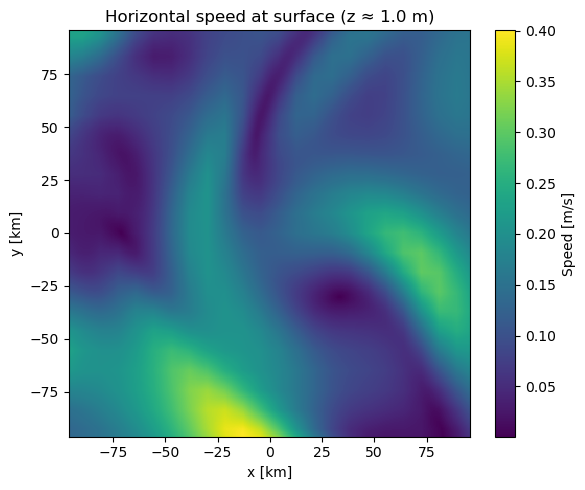

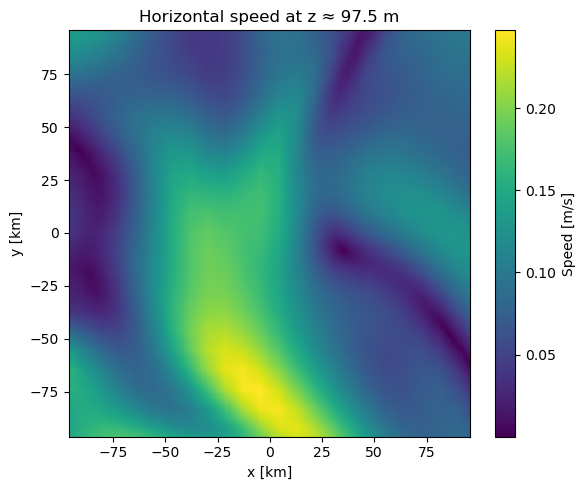

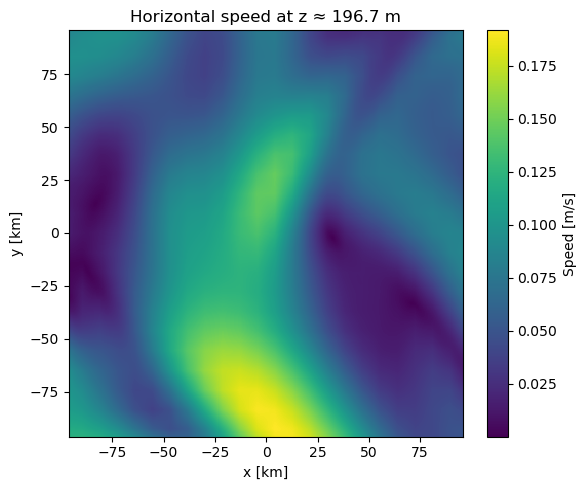

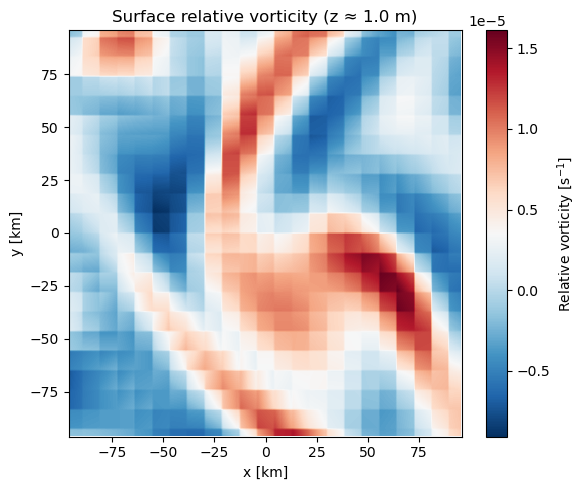

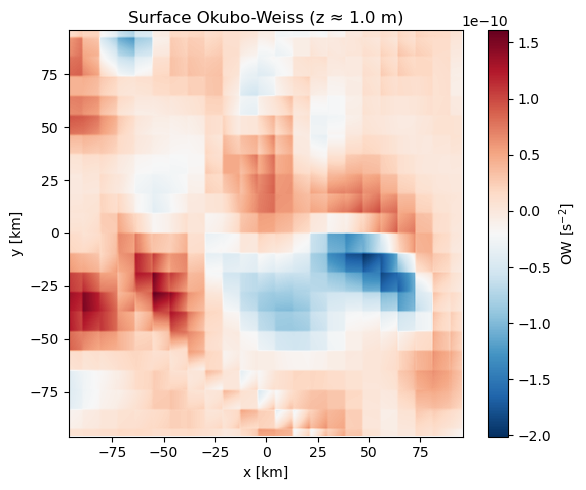

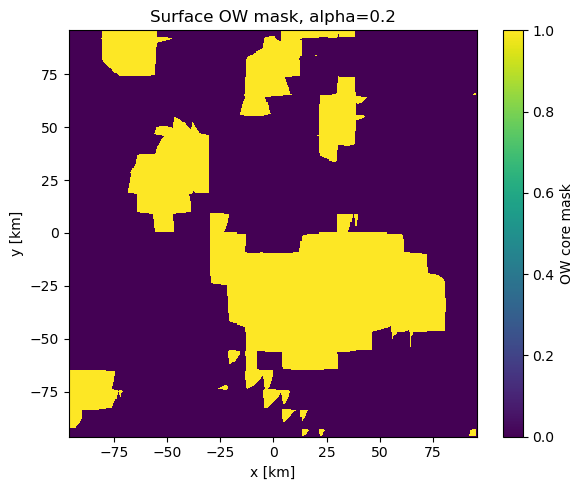

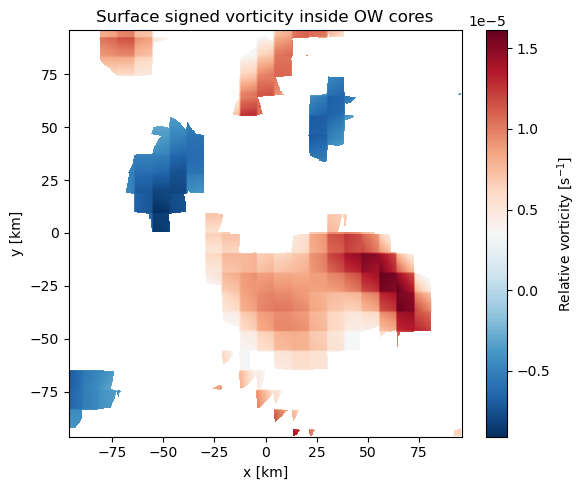

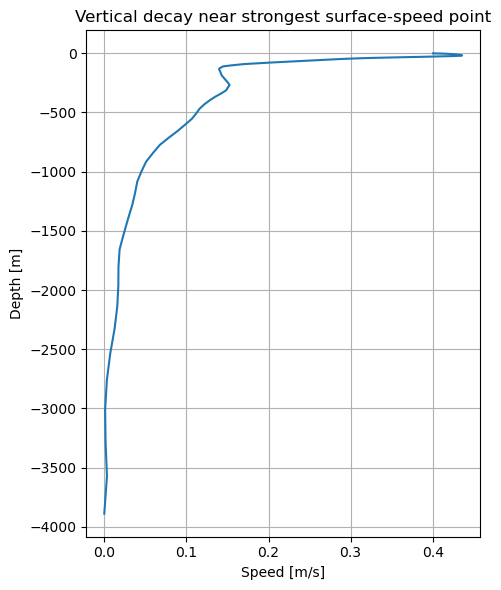

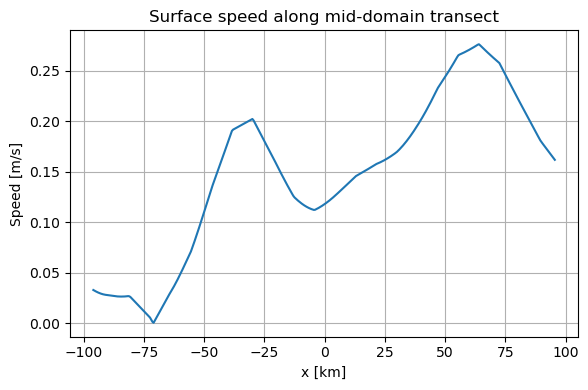

QC complete.
Surface OW threshold = -8.531e-12 s^-2


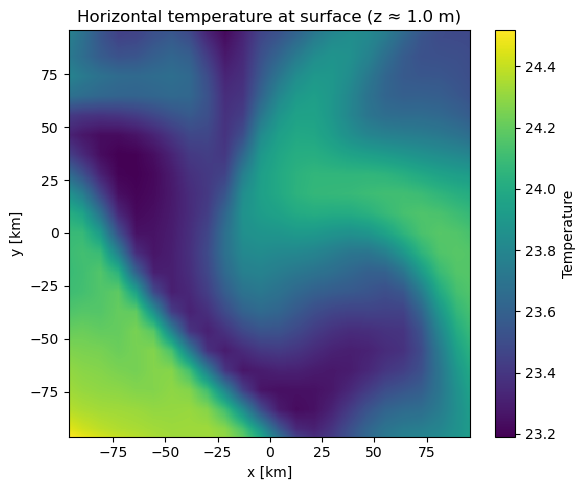

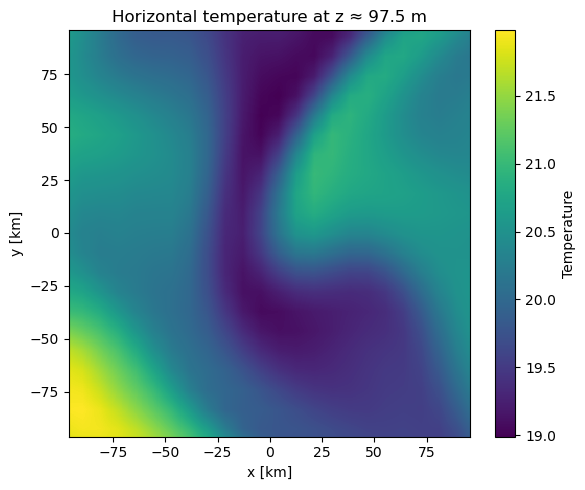

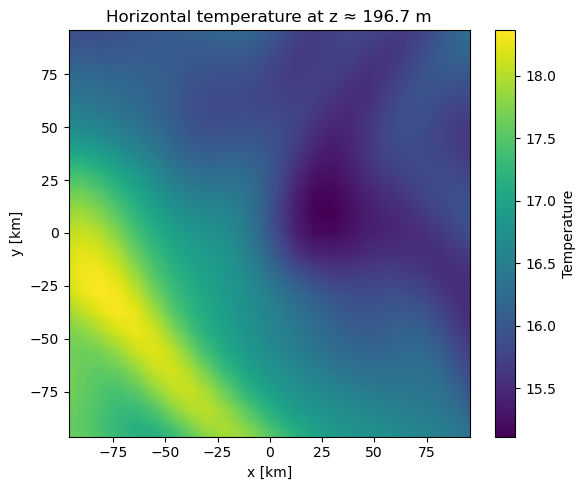

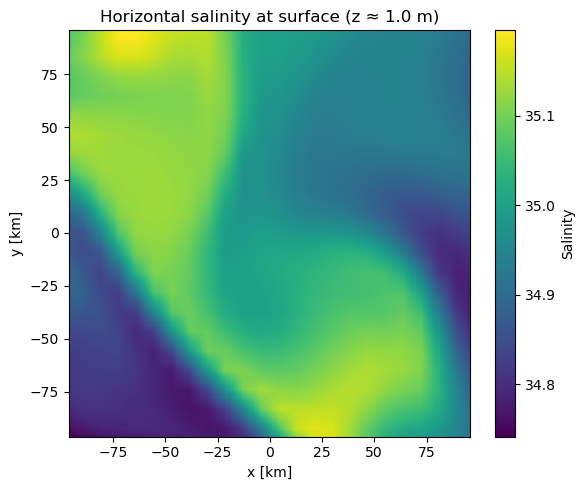

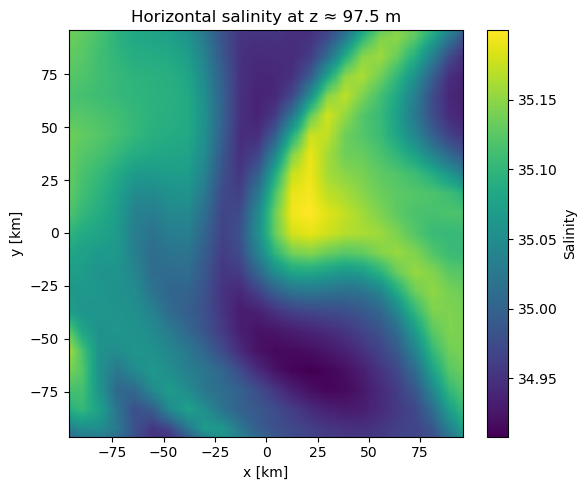

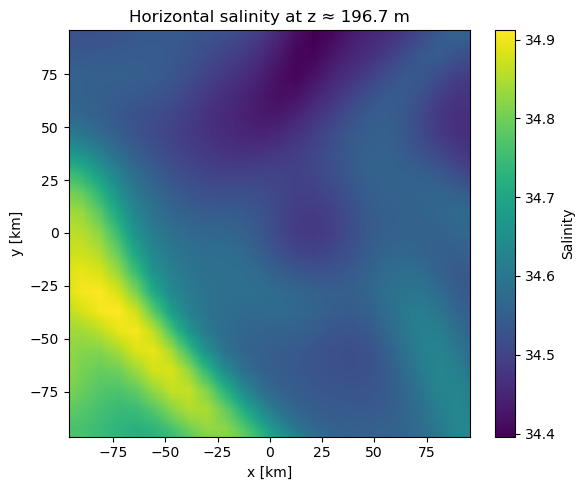

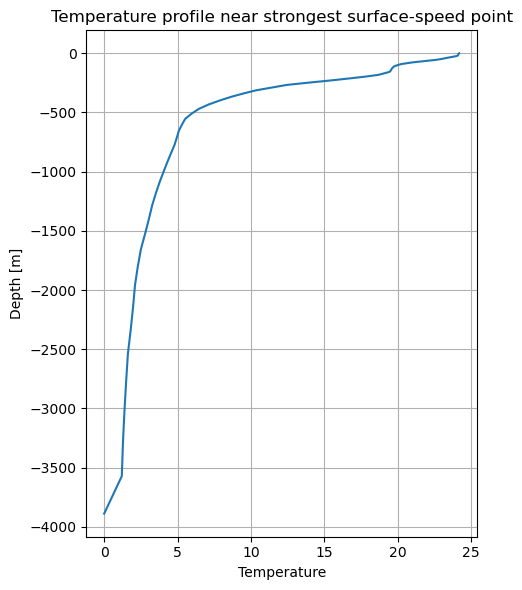

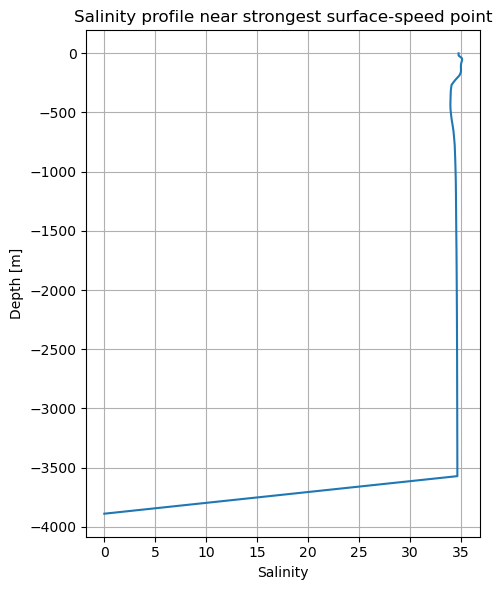

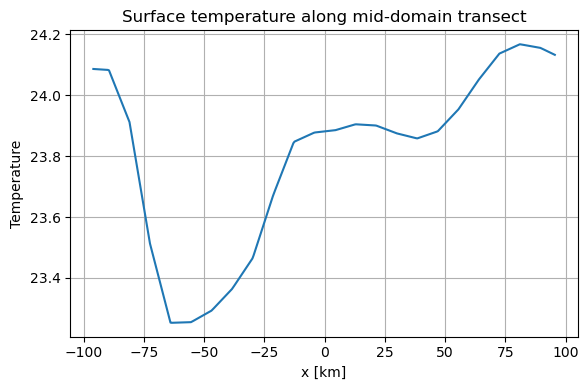

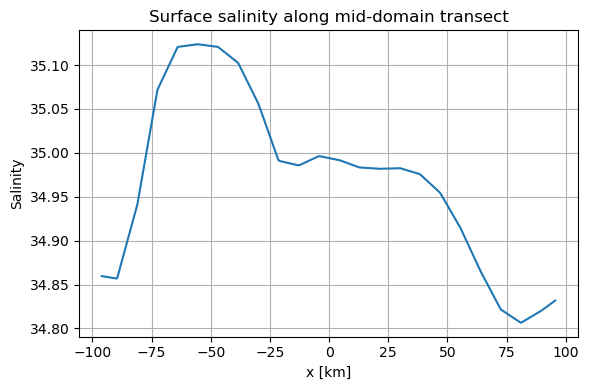

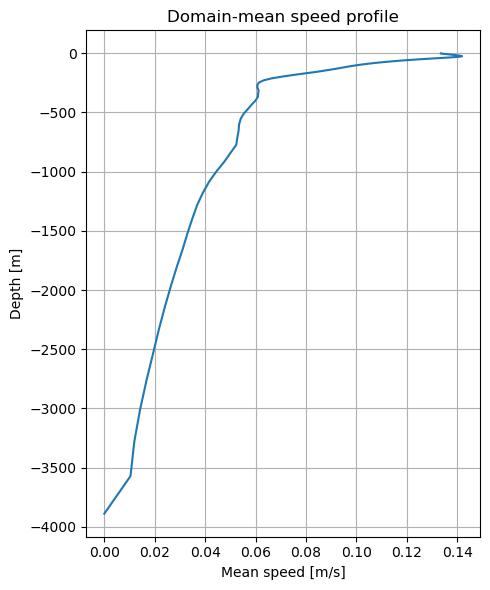

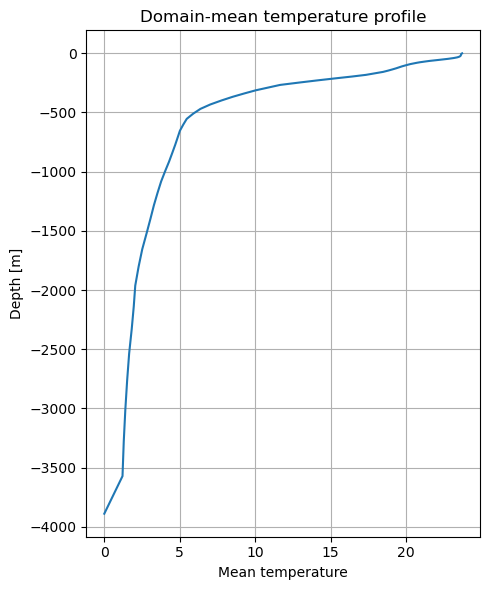

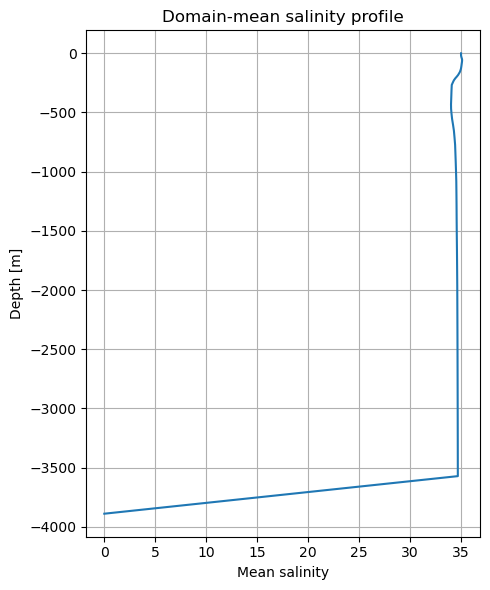

Extended T/S QC complete.


In [3]:
# ------------------------------------------------------------
# Staggered U/V -> cell centers
# ------------------------------------------------------------
u_c = 0.5 * (u_mit[:, :, :-1] + u_mit[:, :, 1:])
v_c = 0.5 * (v_mit[:, :-1, :] + v_mit[:, 1:, :])

ny_plot = min(u_c.shape[1], v_c.shape[1], len(y_mit))
nx_plot = min(u_c.shape[2], v_c.shape[2], len(x_mit))

u_c = u_c[:, :ny_plot, :nx_plot]
v_c = v_c[:, :ny_plot, :nx_plot]
speed3d = np.hypot(u_c, v_c)

X, Y = np.meshgrid(x_mit[:nx_plot], y_mit[:ny_plot])

# ------------------------------------------------------------
# Depth indices
# ------------------------------------------------------------
k_surface = 0
k_100m = np.argmin(np.abs(z_mit - 100.0))
k_200m = np.argmin(np.abs(z_mit - 200.0))

# ------------------------------------------------------------
# Surface vorticity + OW on Cartesian grid
# ------------------------------------------------------------
u_sfc = u_c[k_surface]
v_sfc = v_c[k_surface]

dx = float(np.abs(np.mean(np.gradient(x_mit[:nx_plot]))))
dy = float(np.abs(np.mean(np.gradient(y_mit[:ny_plot]))))

grad_u = np.gradient(u_sfc)
grad_v = np.gradient(v_sfc)

du_dy, du_dx = grad_u[0], grad_u[1]
dv_dy, dv_dx = grad_v[0], grad_v[1]

du_dx = du_dx / dx
dv_dx = dv_dx / dx
du_dy = du_dy / dy
dv_dy = dv_dy / dy

sn = du_dx - dv_dy
ss = dv_dx + du_dy
omega = dv_dx - du_dy
ow_surface = sn**2 + ss**2 - omega**2

# mask outer halo to suppress derivative edge artifacts
halo = 1
for arr in [omega, ow_surface]:
    arr[:halo, :] = np.nan
    arr[-halo:, :] = np.nan
    arr[:, :halo] = np.nan
    arr[:, -halo:] = np.nan

alpha = 0.2
sigma_W = np.nanstd(ow_surface)
ow_threshold = -alpha * sigma_W
ow_mask = np.where(ow_surface < ow_threshold, 1.0, np.nan)
signed_vorticity_masked = np.where(np.isfinite(ow_mask), omega, np.nan)

# ------------------------------------------------------------
# 1) Horizontal speed at surface
# ------------------------------------------------------------
save = True
plt.figure(figsize=(6, 5))
plt.pcolormesh(X / 1000.0, Y / 1000.0, speed3d[k_surface], shading='auto')
plt.colorbar(label='Speed [m/s]')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.title(f'Horizontal speed at surface (z ≈ {z_mit[k_surface]:.1f} m)')
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('horizontal_speed_surface'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 2) Horizontal speed at ~100 m
# ------------------------------------------------------------
save = False
plt.figure(figsize=(6, 5))
plt.pcolormesh(X / 1000.0, Y / 1000.0, speed3d[k_100m], shading='auto')
plt.colorbar(label='Speed [m/s]')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.title(f'Horizontal speed at z ≈ {z_mit[k_100m]:.1f} m')
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('horizontal_speed_100m'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 3) Horizontal speed at ~200 m
# ------------------------------------------------------------
save = False
plt.figure(figsize=(6, 5))
plt.pcolormesh(X / 1000.0, Y / 1000.0, speed3d[k_200m], shading='auto')
plt.colorbar(label='Speed [m/s]')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.title(f'Horizontal speed at z ≈ {z_mit[k_200m]:.1f} m')
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('horizontal_speed_200m'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 4) Surface relative vorticity
# Compare this with your GLORYS vorticity plot
# ------------------------------------------------------------
save = True
plt.figure(figsize=(6, 5))
plt.pcolormesh(X / 1000.0, Y / 1000.0, omega, shading='auto', cmap='RdBu_r')
plt.colorbar(label='Relative vorticity [s$^{-1}$]')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.title(f'Surface relative vorticity (z ≈ {z_mit[k_surface]:.1f} m)')
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('surface_relative_vorticity'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 5) Surface Okubo-Weiss
# ------------------------------------------------------------
save = False
plt.figure(figsize=(6, 5))
plt.pcolormesh(X / 1000.0, Y / 1000.0, ow_surface, shading='auto', cmap='RdBu_r')
plt.colorbar(label='OW [s$^{-2}$]')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.title(f'Surface Okubo-Weiss (z ≈ {z_mit[k_surface]:.1f} m)')
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('surface_okubo_weiss'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 6) Surface OW mask
# ------------------------------------------------------------
save = False
plt.figure(figsize=(6, 5))
plt.pcolormesh(X / 1000.0, Y / 1000.0, np.isfinite(ow_mask), shading='auto')
plt.colorbar(label='OW core mask')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.title(f'Surface OW mask, alpha={alpha}')
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('surface_ow_mask'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 7) Surface signed vorticity inside OW cores
# ------------------------------------------------------------
save = False
plt.figure(figsize=(6, 5))
plt.pcolormesh(X / 1000.0, Y / 1000.0, signed_vorticity_masked, shading='auto', cmap='RdBu_r')
plt.colorbar(label='Relative vorticity [s$^{-1}$]')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.title('Surface signed vorticity inside OW cores')
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('surface_signed_vorticity_in_ow_cores'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 8) Vertical profile at strongest surface-speed point
# ------------------------------------------------------------
save = False
iy_peak, ix_peak = np.unravel_index(np.nanargmax(speed3d[k_surface]), speed3d[k_surface].shape)
profile_peak = speed3d[:, iy_peak, ix_peak]

plt.figure(figsize=(5, 6))
plt.plot(profile_peak, -z_mit)
plt.xlabel('Speed [m/s]')
plt.ylabel('Depth [m]')
plt.title('Vertical decay near strongest surface-speed point')
plt.grid(True)
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('vertical_decay_profile'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 9) Surface speed along mid-domain transect
# ------------------------------------------------------------
save = False
iy_mid = ny_plot // 2
surface_profile = speed3d[k_surface, iy_mid, :]

plt.figure(figsize=(6, 4))
plt.plot(x_mit[:nx_plot] / 1000.0, surface_profile)
plt.xlabel('x [km]')
plt.ylabel('Speed [m/s]')
plt.title('Surface speed along mid-domain transect')
plt.grid(True)
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('surface_speed_transect'), format=save_format, bbox_inches='tight')
plt.show()

print("QC complete.")
print(f"Surface OW threshold = {ow_threshold:.3e} s^-2")

# ------------------------------------------------------------
# T / S fields on tracer grid
# ------------------------------------------------------------
theta3d = theta_mit[:, :ny_plot, :nx_plot]
salt3d  = salt_mit[:, :ny_plot, :nx_plot]

# ------------------------------------------------------------
# 10) Horizontal temperature at surface
# ------------------------------------------------------------
save = True
plt.figure(figsize=(6, 5))
plt.pcolormesh(X / 1000.0, Y / 1000.0, theta3d[k_surface], shading='auto')
plt.colorbar(label='Temperature')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.title(f'Horizontal temperature at surface (z ≈ {z_mit[k_surface]:.1f} m)')
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('horizontal_temperature_surface'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 11) Horizontal temperature at ~100 m
# ------------------------------------------------------------
save = False
plt.figure(figsize=(6, 5))
plt.pcolormesh(X / 1000.0, Y / 1000.0, theta3d[k_100m], shading='auto')
plt.colorbar(label='Temperature')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.title(f'Horizontal temperature at z ≈ {z_mit[k_100m]:.1f} m')
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('horizontal_temperature_100m'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 12) Horizontal temperature at ~200 m
# ------------------------------------------------------------
save = False
plt.figure(figsize=(6, 5))
plt.pcolormesh(X / 1000.0, Y / 1000.0, theta3d[k_200m], shading='auto')
plt.colorbar(label='Temperature')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.title(f'Horizontal temperature at z ≈ {z_mit[k_200m]:.1f} m')
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('horizontal_temperature_200m'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 13) Horizontal salinity at surface
# ------------------------------------------------------------
save = True
plt.figure(figsize=(6, 5))
plt.pcolormesh(X / 1000.0, Y / 1000.0, salt3d[k_surface], shading='auto')
plt.colorbar(label='Salinity')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.title(f'Horizontal salinity at surface (z ≈ {z_mit[k_surface]:.1f} m)')
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('horizontal_salinity_surface'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 14) Horizontal salinity at ~100 m
# ------------------------------------------------------------
save = False
plt.figure(figsize=(6, 5))
plt.pcolormesh(X / 1000.0, Y / 1000.0, salt3d[k_100m], shading='auto')
plt.colorbar(label='Salinity')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.title(f'Horizontal salinity at z ≈ {z_mit[k_100m]:.1f} m')
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('horizontal_salinity_100m'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 15) Horizontal salinity at ~200 m
# ------------------------------------------------------------
save = False
plt.figure(figsize=(6, 5))
plt.pcolormesh(X / 1000.0, Y / 1000.0, salt3d[k_200m], shading='auto')
plt.colorbar(label='Salinity')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.title(f'Horizontal salinity at z ≈ {z_mit[k_200m]:.1f} m')
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('horizontal_salinity_200m'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 16) Vertical temperature profile at strongest surface-speed point
# ------------------------------------------------------------
save = False
theta_profile_peak = theta3d[:, iy_peak, ix_peak]

plt.figure(figsize=(5, 6))
plt.plot(theta_profile_peak, -z_mit)
plt.xlabel('Temperature')
plt.ylabel('Depth [m]')
plt.title('Temperature profile near strongest surface-speed point')
plt.grid(True)
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('vertical_temperature_profile'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 17) Vertical salinity profile at strongest surface-speed point
# ------------------------------------------------------------
save = False
salt_profile_peak = salt3d[:, iy_peak, ix_peak]

plt.figure(figsize=(5, 6))
plt.plot(salt_profile_peak, -z_mit)
plt.xlabel('Salinity')
plt.ylabel('Depth [m]')
plt.title('Salinity profile near strongest surface-speed point')
plt.grid(True)
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('vertical_salinity_profile'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 18) Surface temperature along mid-domain transect
# ------------------------------------------------------------
save = False
theta_surface_profile = theta3d[k_surface, iy_mid, :]

plt.figure(figsize=(6, 4))
plt.plot(x_mit[:nx_plot] / 1000.0, theta_surface_profile)
plt.xlabel('x [km]')
plt.ylabel('Temperature')
plt.title('Surface temperature along mid-domain transect')
plt.grid(True)
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('surface_temperature_transect'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 19) Surface salinity along mid-domain transect
# ------------------------------------------------------------
save = False
salt_surface_profile = salt3d[k_surface, iy_mid, :]

plt.figure(figsize=(6, 4))
plt.plot(x_mit[:nx_plot] / 1000.0, salt_surface_profile)
plt.xlabel('x [km]')
plt.ylabel('Salinity')
plt.title('Surface salinity along mid-domain transect')
plt.grid(True)
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('surface_salinity_transect'), format=save_format, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 20) Domain-mean vertical profiles of speed, T, and S
# ------------------------------------------------------------
save = False
speed_mean_z = np.nanmean(speed3d, axis=(1, 2))
theta_mean_z = np.nanmean(theta3d, axis=(1, 2))
salt_mean_z  = np.nanmean(salt3d, axis=(1, 2))

plt.figure(figsize=(5, 6))
plt.plot(speed_mean_z, -z_mit)
plt.xlabel('Mean speed [m/s]')
plt.ylabel('Depth [m]')
plt.title('Domain-mean speed profile')
plt.grid(True)
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('domain_mean_speed_profile'), format=save_format, bbox_inches='tight')
plt.show()

plt.figure(figsize=(5, 6))
plt.plot(theta_mean_z, -z_mit)
plt.xlabel('Mean temperature')
plt.ylabel('Depth [m]')
plt.title('Domain-mean temperature profile')
plt.grid(True)
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('domain_mean_temperature_profile'), format=save_format, bbox_inches='tight')
plt.show()

plt.figure(figsize=(5, 6))
plt.plot(salt_mean_z, -z_mit)
plt.xlabel('Mean salinity')
plt.ylabel('Depth [m]')
plt.title('Domain-mean salinity profile')
plt.grid(True)
plt.tight_layout()
if save:
    plt.savefig(figure_output_path('domain_mean_salinity_profile'), format=save_format, bbox_inches='tight')
plt.show()

print("Extended T/S QC complete.")



Interpolation-check transects (matched nearest-to-nearest)
MITgcm target depth         : 97.50 m
Chosen GLORYS row y         : 0.000 km
Nearest MITgcm row y        : 0.000 km
Chosen GLORYS column x      : -4.265 km
Nearest MITgcm column x     : -4.500 km


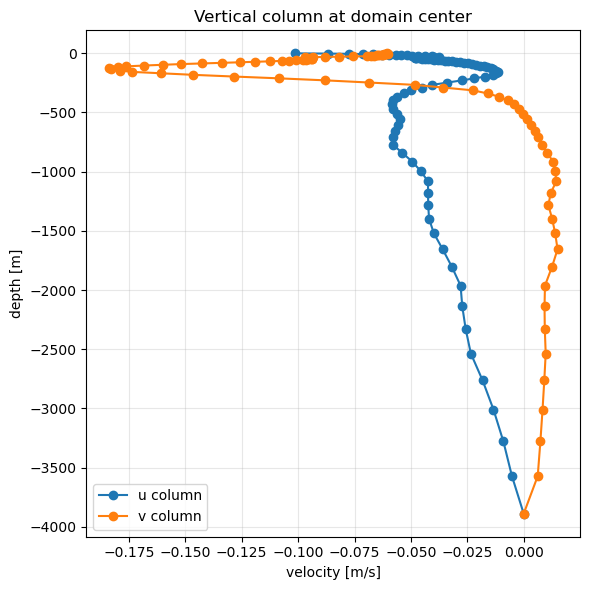

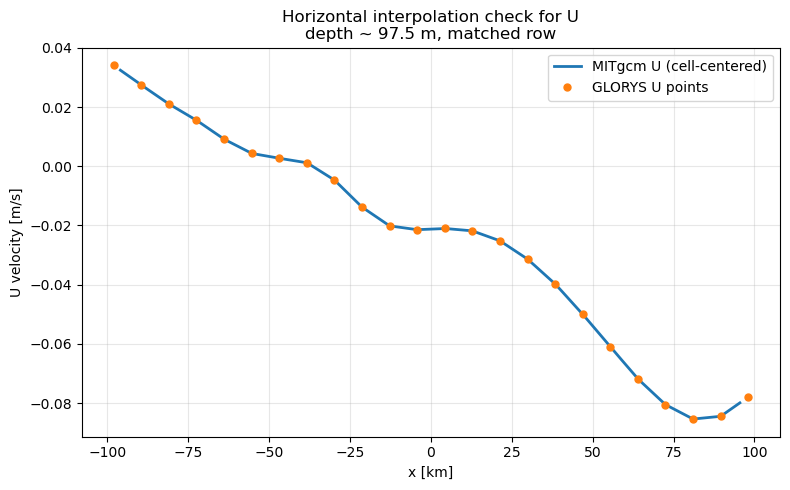

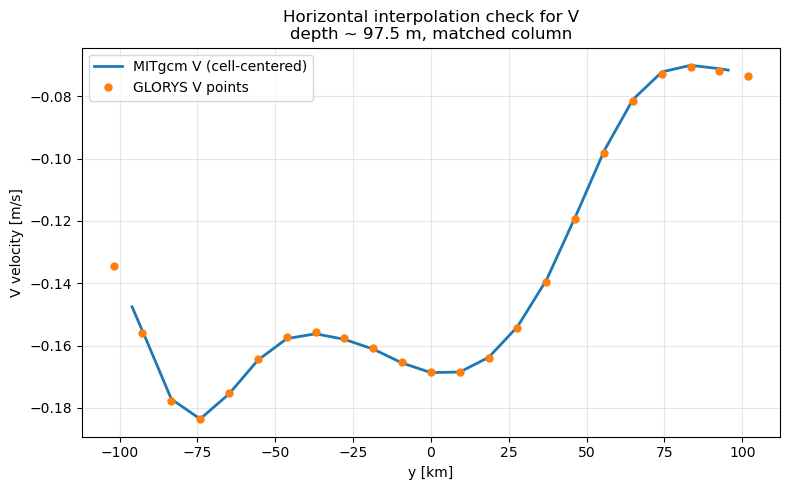


Interpolation-check transects for T/S
MITgcm target depth         : 97.50 m
Chosen GLORYS row y         : 0.000 km
Nearest MITgcm tracer row y : 0.000 km


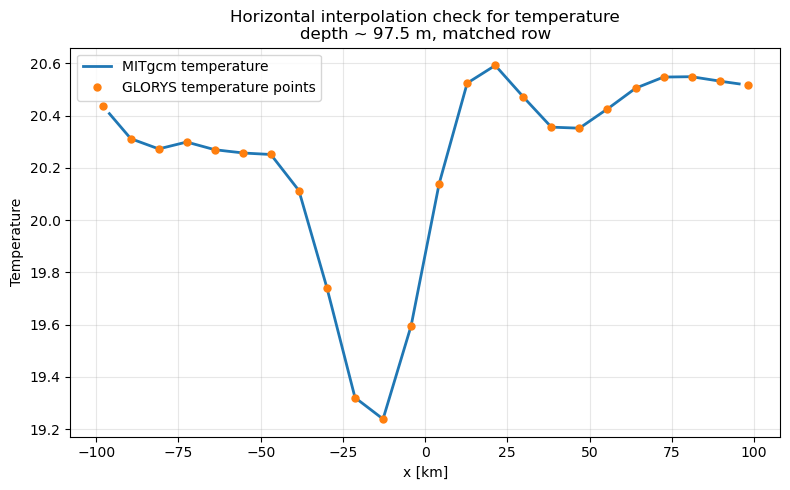

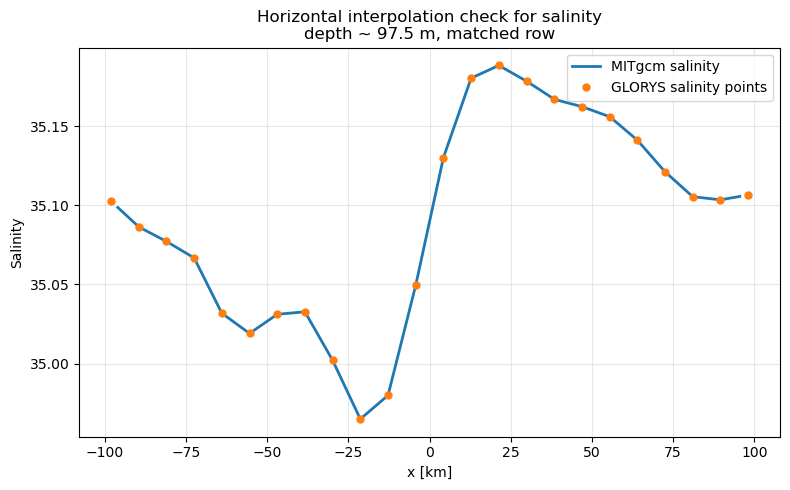


Vertical interpolation check for T/S
Chosen MITgcm tracer point : x = -4.500 km, y = 0.000 km
Nearest GLORYS point       : x = -4.265 km, y = 0.000 km


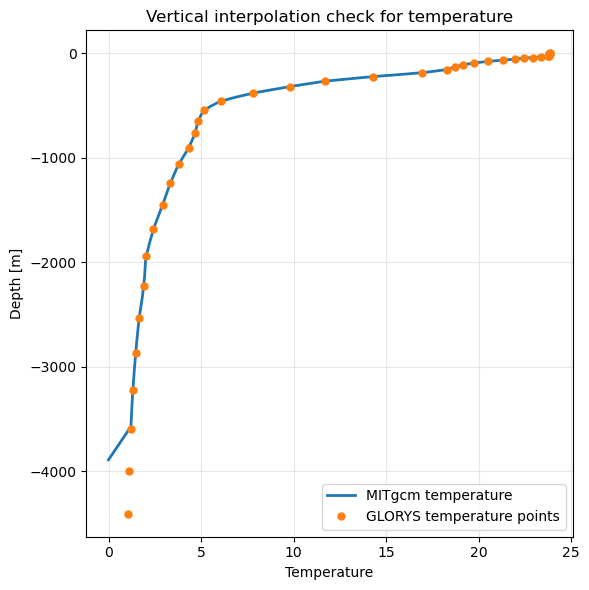

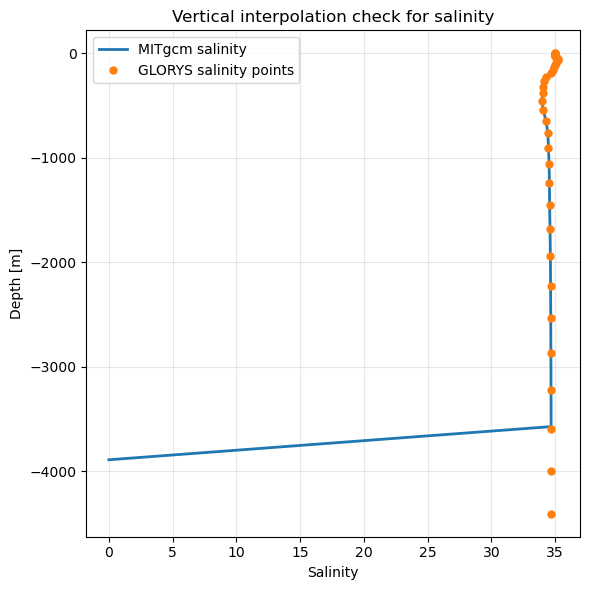

In [7]:
# ------------------------------------------------------------
# INTERPOLATION CHECK: use nearest MITgcm transect to GLORYS
# ------------------------------------------------------------

src_nc = input_nc

def find_first_present(ds, names):
    for n in names:
        if n in ds.variables or n in ds.coords:
            return n
    return None

# ------------------------------------------------------------
# Open native GLORYS file
# ------------------------------------------------------------
ds_src = xr.open_dataset(src_nc)

u_name = find_first_present(ds_src, ["uo", "UO", "u", "U"])
v_name = find_first_present(ds_src, ["vo", "VO", "v", "V"])
lon_name = find_first_present(ds_src, ["longitude", "lon", "nav_lon"])
lat_name = find_first_present(ds_src, ["latitude", "lat", "nav_lat"])
z_name = find_first_present(ds_src, ["depth", "lev", "z"])
time_name = find_first_present(ds_src, ["time", "TIME"])

u_src_da = ds_src[u_name]
v_src_da = ds_src[v_name]

if time_name and time_name in u_src_da.dims:
    u_src_da = u_src_da.isel({time_name: 0})
if time_name and time_name in v_src_da.dims:
    v_src_da = v_src_da.isel({time_name: 0})

u_src_da = u_src_da.transpose(z_name, lat_name, lon_name).sortby(lat_name).sortby(lon_name)
v_src_da = v_src_da.transpose(z_name, lat_name, lon_name).sortby(lat_name).sortby(lon_name)

lon_src = u_src_da[lon_name].values.astype(float)
lat_src = u_src_da[lat_name].values.astype(float)

# ------------------------------------------------------------
# Target depth
# ------------------------------------------------------------
k_plot = k_100m
z_plot = float(z_mit[k_plot])

# interpolate GLORYS vertically to MITgcm plot depth
u_src_z = u_src_da.interp({z_name: z_plot}).values   # (lat, lon)
v_src_z = v_src_da.interp({z_name: z_plot}).values   # (lat, lon)

# ------------------------------------------------------------
# Convert native GLORYS lon/lat to same local x/y frame
# ------------------------------------------------------------
Re = 6371000.0
lon0 = 0.5 * (float(lon_src.min()) + float(lon_src.max()))
lat0 = 0.5 * (float(lat_src.min()) + float(lat_src.max()))

x_src = (lon_src - lon0) * np.pi / 180.0 * Re * np.cos(np.deg2rad(lat0))
y_src = (lat_src - lat0) * np.pi / 180.0 * Re

# ------------------------------------------------------------
# Choose GLORYS transects nearest the MITgcm domain center
# ------------------------------------------------------------
j_src = int(np.argmin(np.abs(y_src - 0.0)))   # GLORYS row nearest y=0
i_src = int(np.argmin(np.abs(x_src - 0.0)))   # GLORYS column nearest x=0

# ------------------------------------------------------------
# Now choose the NEAREST MITgcm transects to those GLORYS ones
# This is the key fix
# ------------------------------------------------------------
iy_cmp = int(np.argmin(np.abs(y_mit[:ny_plot] - y_src[j_src])))
ix_cmp = int(np.argmin(np.abs(x_mit[:nx_plot] - x_src[i_src])))

print("\nInterpolation-check transects (matched nearest-to-nearest)")
print(f"MITgcm target depth         : {z_plot:.2f} m")
print(f"Chosen GLORYS row y         : {y_src[j_src]/1000:.3f} km")
print(f"Nearest MITgcm row y        : {y_mit[iy_cmp]/1000:.3f} km")
print(f"Chosen GLORYS column x      : {x_src[i_src]/1000:.3f} km")
print(f"Nearest MITgcm column x     : {x_mit[ix_cmp]/1000:.3f} km")

# ------------------------------------------------------------
# 1) Vertical column at domain center
# ------------------------------------------------------------
iy_mid = ny_plot // 2
ix_mid = nx_plot // 2

plt.figure(figsize=(6, 6))
plt.plot(u_c[:, iy_mid, ix_mid], -z_mit, marker="o", label="u column")
plt.plot(v_c[:, iy_mid, ix_mid], -z_mit, marker="o", label="v column")
plt.xlabel("velocity [m/s]")
plt.ylabel("depth [m]")
plt.title("Vertical column at domain center")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2) U transect: nearest MITgcm row to chosen GLORYS row
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(x_mit[:nx_plot] / 1000.0, u_c[k_plot, iy_cmp, :], "-", lw=2, label="MITgcm U (cell-centered)")
plt.plot(x_src / 1000.0, u_src_z[j_src, :], "o", ms=5, label="GLORYS U points")
plt.xlabel("x [km]")
plt.ylabel("U velocity [m/s]")
plt.title(f"Horizontal interpolation check for U\ndepth ~ {z_plot:.1f} m, matched row")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3) V transect: nearest MITgcm column to chosen GLORYS column
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(y_mit[:ny_plot] / 1000.0, v_c[k_plot, :, ix_cmp], "-", lw=2, label="MITgcm V (cell-centered)")
plt.plot(y_src / 1000.0, v_src_z[:, i_src], "o", ms=5, label="GLORYS V points")
plt.xlabel("y [km]")
plt.ylabel("V velocity [m/s]")
plt.title(f"Horizontal interpolation check for V\ndepth ~ {z_plot:.1f} m, matched column")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

theta_name = find_first_present(ds_src, ["thetao", "THETAO", "theta", "THETA", "temperature", "temp", "TEMP"])
salt_name  = find_first_present(ds_src, ["so", "SO", "salt", "SALT", "salinity", "vosaline"])

theta_src_da = ds_src[theta_name]
salt_src_da  = ds_src[salt_name]

if time_name and time_name in theta_src_da.dims:
    theta_src_da = theta_src_da.isel({time_name: 0})
if time_name and time_name in salt_src_da.dims:
    salt_src_da = salt_src_da.isel({time_name: 0})

theta_src_da = theta_src_da.transpose(z_name, lat_name, lon_name).sortby(lat_name).sortby(lon_name)
salt_src_da  = salt_src_da.transpose(z_name, lat_name, lon_name).sortby(lat_name).sortby(lon_name)

# interpolate native GLORYS vertically to MITgcm plot depth
theta_src_z = theta_src_da.interp({z_name: z_plot}).values   # (lat, lon)
salt_src_z  = salt_src_da.interp({z_name: z_plot}).values    # (lat, lon)

# tracer fields on MITgcm grid
theta3d = theta_mit[:, :ny_plot, :nx_plot]
salt3d  = salt_mit[:, :ny_plot, :nx_plot]

# choose nearest MITgcm tracer row to chosen GLORYS row
iy_t_cmp = int(np.argmin(np.abs(y_mit[:ny_plot] - y_src[j_src])))

print("\nInterpolation-check transects for T/S")
print(f"MITgcm target depth         : {z_plot:.2f} m")
print(f"Chosen GLORYS row y         : {y_src[j_src]/1000:.3f} km")
print(f"Nearest MITgcm tracer row y : {y_mit[iy_t_cmp]/1000:.3f} km")

# ------------------------------------------------------------
# Temperature transect
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(x_mit[:nx_plot] / 1000.0, theta3d[k_plot, iy_t_cmp, :], "-", lw=2, label="MITgcm temperature")
plt.plot(x_src / 1000.0, theta_src_z[j_src, :], "o", ms=5, label="GLORYS temperature points")
plt.xlabel("x [km]")
plt.ylabel("Temperature")
plt.title(f"Horizontal interpolation check for temperature\ndepth ~ {z_plot:.1f} m, matched row")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Salinity transect
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(x_mit[:nx_plot] / 1000.0, salt3d[k_plot, iy_t_cmp, :], "-", lw=2, label="MITgcm salinity")
plt.plot(x_src / 1000.0, salt_src_z[j_src, :], "o", ms=5, label="GLORYS salinity points")
plt.xlabel("x [km]")
plt.ylabel("Salinity")
plt.title(f"Horizontal interpolation check for salinity\ndepth ~ {z_plot:.1f} m, matched row")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# VERTICAL INTERPOLATION CHECK FOR T AND S
# ------------------------------------------------------------

# nearest MITgcm tracer point to the chosen GLORYS center-near location
iy_t_vert = int(np.argmin(np.abs(y_mit[:ny_plot] - y_src[j_src])))
ix_t_vert = int(np.argmin(np.abs(x_mit[:nx_plot] - x_src[i_src])))

# nearest GLORYS point to that MITgcm tracer point
j_src_vert = int(np.argmin(np.abs(y_src - y_mit[iy_t_vert])))
i_src_vert = int(np.argmin(np.abs(x_src - x_mit[ix_t_vert])))

print("\nVertical interpolation check for T/S")
print(f"Chosen MITgcm tracer point : x = {x_mit[ix_t_vert]/1000:.3f} km, y = {y_mit[iy_t_vert]/1000:.3f} km")
print(f"Nearest GLORYS point       : x = {x_src[i_src_vert]/1000:.3f} km, y = {y_src[j_src_vert]/1000:.3f} km")

# native GLORYS vertical columns at nearest source point
theta_src_col = theta_src_da[:, j_src_vert, i_src_vert].values.astype(float)
salt_src_col  = salt_src_da[:, j_src_vert, i_src_vert].values.astype(float)

# MITgcm interpolated vertical columns at nearest tracer point
theta_mit_col = theta3d[:, iy_t_vert, ix_t_vert]
salt_mit_col  = salt3d[:, iy_t_vert, ix_t_vert]

# ------------------------------------------------------------
# Temperature vertical interpolation check
# ------------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.plot(theta_mit_col, -z_mit, '-', lw=2, label='MITgcm temperature')
plt.plot(theta_src_col, -theta_src_da[z_name].values.astype(float), 'o', ms=5, label='GLORYS temperature points')
plt.xlabel('Temperature')
plt.ylabel('Depth [m]')
plt.title('Vertical interpolation check for temperature')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Salinity vertical interpolation check
# ------------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.plot(salt_mit_col, -z_mit, '-', lw=2, label='MITgcm salinity')
plt.plot(salt_src_col, -salt_src_da[z_name].values.astype(float), 'o', ms=5, label='GLORYS salinity points')
plt.xlabel('Salinity')
plt.ylabel('Depth [m]')
plt.title('Vertical interpolation check for salinity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()